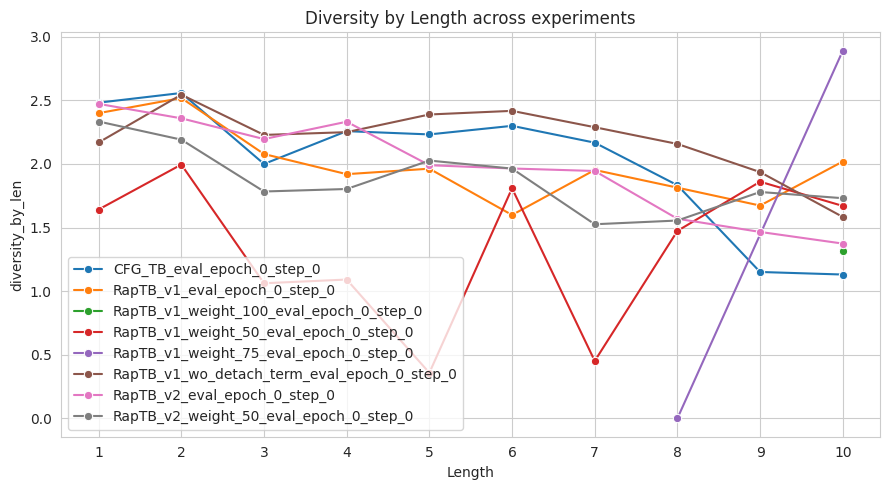

In [4]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

eval_dir = Path("/data1/xw3763/project/gflow/ChemGFN/evaluation")
file_paths = sorted(eval_dir.glob("test_metrics_smiles_*.json"))

def load_diversity(fp: Path):
    with fp.open() as f:
        data = json.load(f)
    label = fp.stem.replace("test_metrics_smiles_", "")
    return label, {int(k): float(v) for k, v in data["diversity_by_len"].items()}

series = [load_diversity(fp) for fp in file_paths]
all_lengths = sorted({k for _, d in series for k in d.keys()})

sns.set_style("whitegrid")
plt.figure(figsize=(9, 5))

palette = sns.color_palette("tab10", n_colors=len(series))
for (label, div_map), color in zip(series, palette):
    y = [div_map.get(L, np.nan) for L in all_lengths]
    sns.lineplot(x=all_lengths, y=y, marker="o", label=label, color=color)

plt.xlabel("Length")
plt.ylabel("diversity_by_len")
plt.title("Diversity by Length across experiments")
plt.xticks(all_lengths)
plt.tight_layout()
plt.show()